# Загрузка библиотек и объединение файлов Лента

In [2]:
import pandas as pd
import networkx as nx
from itertools import combinations
from collections import Counter
import numpy as np
import igraph as ig
import leidenalg
import gc
import matplotlib.pyplot as plt

OUTPUT_FILE_1 = ('/Users/veronikakozlova/Downloads/Для студентов/выгрузка_студенты_окт-дек_часть_1.csv')
OUTPUT_FILE_2 = ('/Users/veronikakozlova/Downloads/Для студентов/выгрузка_студенты_окт-дек_часть_2.csv')
OUTPUT_FILE_3 = ('/Users/veronikakozlova/Downloads/Для студентов/выгрузка_студенты_окт-дек_часть_3.csv')
OUTPUT_FILE_4 = ('/Users/veronikakozlova/Downloads/Для студентов/выгрузка_студенты_окт-дек_часть_4.csv')

df_1 = pd.read_csv(OUTPUT_FILE_1, sep = ';')
df_2 = pd.read_csv(OUTPUT_FILE_2, sep = ';')
df_3 = pd.read_csv(OUTPUT_FILE_3, sep = ';')
df_4 = pd.read_csv(OUTPUT_FILE_4, sep = ';')

df = pd.concat([df_1, df_2, df_3, df_4], ignore_index=True)

# Описательная статистика

## При очистке от выбросов

Общее количество чеков: 13726004
Общее количество позиций (строк): 121429679
Общий объём проданных товаров (штук): 225336132.44099924
Среднее количество единиц на чек (до очистки): 16.50
Уникальных категорий: 496
Уникальных подкатегорий: 2134

--- Размер чека (ПОСЛЕ очистки) ---
Чеков осталось: 13404047
Среднее: 15.12
Медиана: 8.83
Стандартное отклонение: 17.76
Минимум: 1.0
Максимум: 111.734
95-й перцентиль: 53.29


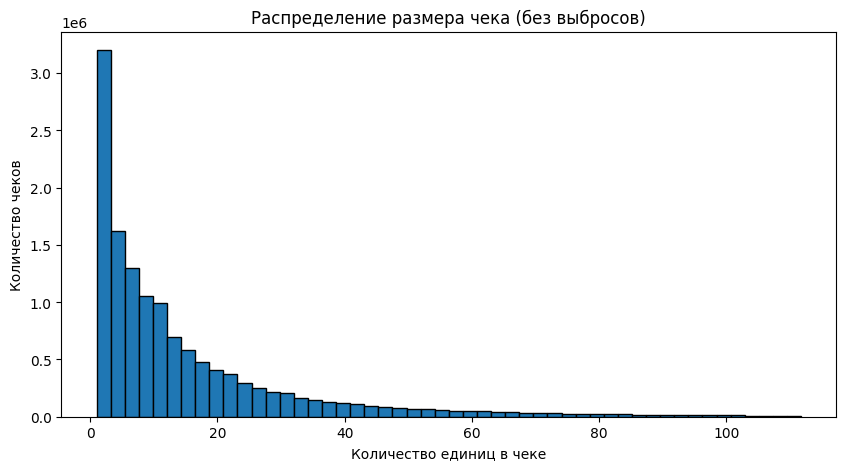


--- Подкатегории в чеке (ПОСЛЕ очистки) ---
Среднее: 8.45
Медиана: 6.00
Стандартное отклонение: 7.89
Минимум: 1
Максимум: 43
95-й перцентиль: 25.00

Топ-10 категорий по доле чеков:
cat_name
Упаковочные и подсобные материалы                 34.76
Хлеб промышленный ржаной, ржано-пшеничный         13.85
Хлеб промышленный пшеничный                       13.85
Вода                                              13.24
Хлеб собственное производство                     12.31
Томаты                                            12.30
Молоко пастеризованное                            12.18
Йогурты и творожные десерты холодного хранения    11.83
Огурцы                                            11.62
Лимонады                                          11.29
Name: ChequeId, dtype: float64


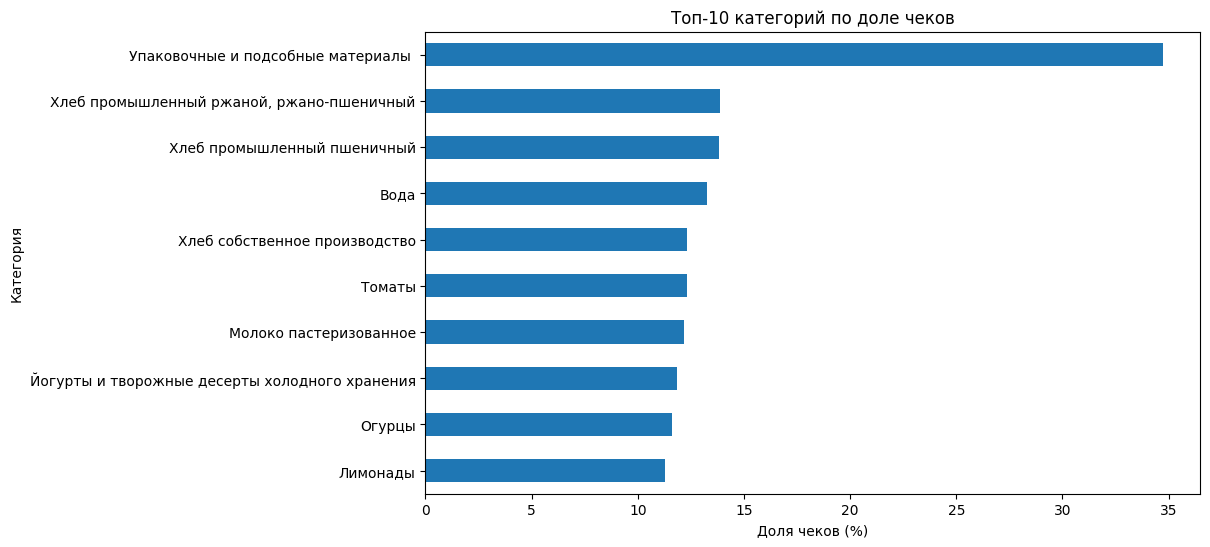


Топ-10 категорий по объему продаж (штуки):
cat_name
Йогурты и творожные десерты холодного хранения    7986308.000
Продукты для кошек                                7505492.000
Упаковочные и подсобные материалы                 7048251.000
Вода                                              5483674.000
Шоколадные батончики                              4373946.000
Соки, нектары, морсы                              3813862.000
Лимонады                                          3511351.000
Сладости для детей                                3375132.670
Хлеб собственное производство                     3256514.298
Шоколадные плитки                                 3178892.000
Name: Штуки товаров в категории, dtype: float64

Топ-10 категорий по среднему количеству на чек:
cat_name
Подарок за покупку            14.63
Птица охлажденная (сырье)     12.00
Продукты для кошек            11.83
Пиротехника                   10.12
Готовое детское питание        9.79
Елочные украшения              9.33
Товар

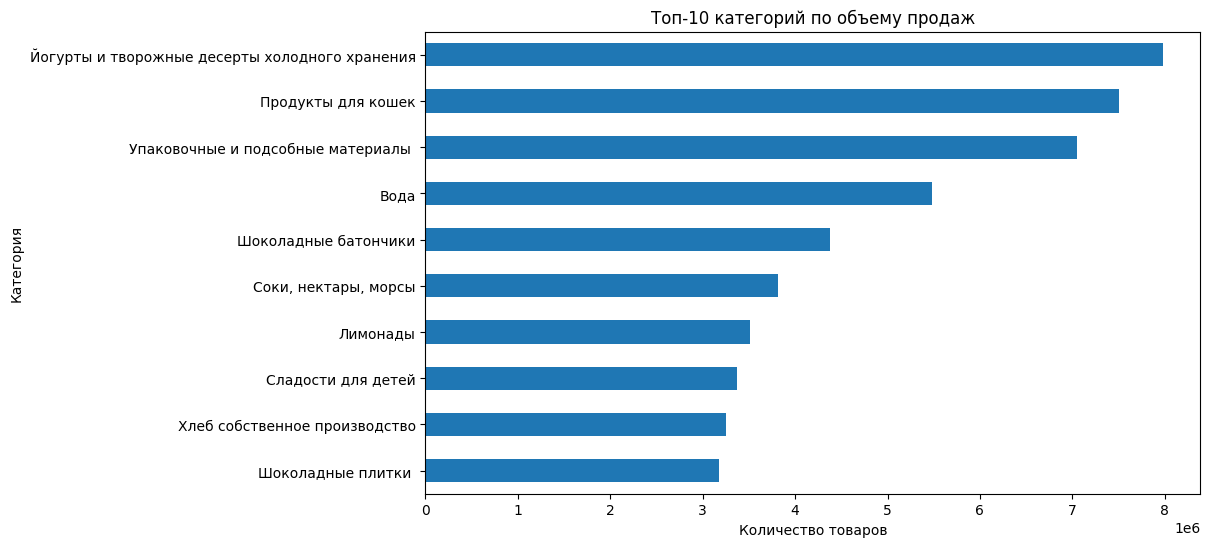

In [3]:
# Общее количество уникальных чеков
total_cheques = df['ChequeId'].nunique()
print(f"Общее количество чеков: {total_cheques}")

# Общее количество строк
total_rows = len(df)
print(f"Общее количество позиций (строк): {total_rows}")

# Метрики объема продаж

if 'Штуки товаров в категории' in df.columns:
    total_units = df['Штуки товаров в категории'].sum()
    print(f"Общий объём проданных товаров (штук): {total_units}")
    
    # Размер чека (в штуках)
    cheque_sizes = df.groupby('ChequeId')['Штуки товаров в категории'].sum()
    
    # Убираем отрицательные значения (возвраты / ошибки)
    cheque_sizes = cheque_sizes[cheque_sizes >= 0]
    
    print(f"Среднее количество единиц на чек (до очистки): {cheque_sizes.mean():.2f}")
else:
    print("Колонка с количеством не найдена.")
    cheque_sizes = None

# Уникальные категории

if 'cat_name' in df.columns:
    unique_cats = df['cat_name'].nunique()
    print(f"Уникальных категорий: {unique_cats}")

unique_subcats = df['sub_cat_name'].nunique()
print(f"Уникальных подкатегорий: {unique_subcats}")

# Очистка выбросов (размер чека)
if cheque_sizes is not None:
    
    lower_bound = cheque_sizes.quantile(0.01)
    upper_bound = cheque_sizes.quantile(0.99)
    
    cheque_sizes_filtered = cheque_sizes[
        (cheque_sizes >= lower_bound) &
        (cheque_sizes <= upper_bound)
    ]
    
    print("\n--- Размер чека (ПОСЛЕ очистки) ---")
    print(f"Чеков осталось: {len(cheque_sizes_filtered)}")
    print(f"Среднее: {cheque_sizes_filtered.mean():.2f}")
    print(f"Медиана: {cheque_sizes_filtered.median():.2f}")
    print(f"Стандартное отклонение: {cheque_sizes_filtered.std():.2f}")
    print(f"Минимум: {cheque_sizes_filtered.min()}")
    print(f"Максимум: {cheque_sizes_filtered.max()}")
    print(f"95-й перцентиль: {cheque_sizes_filtered.quantile(0.95):.2f}")
    
    # Гистограмма без выбросов
    plt.figure(figsize=(10,5))
    plt.hist(cheque_sizes_filtered, bins=50, edgecolor='black')
    plt.title('Распределение размера чека (без выбросов)')
    plt.xlabel('Количество единиц в чеке')
    plt.ylabel('Количество чеков')
    plt.show()

# Количество уникальных подкатегорий в чеке

unique_subcats_per_cheque = df.groupby('ChequeId')['sub_cat_name'].nunique()

# Очистка выбросов
lower_bound_sub = unique_subcats_per_cheque.quantile(0.01)
upper_bound_sub = unique_subcats_per_cheque.quantile(0.99)

unique_subcats_filtered = unique_subcats_per_cheque[
    (unique_subcats_per_cheque >= lower_bound_sub) &
    (unique_subcats_per_cheque <= upper_bound_sub)
]

print("\n--- Подкатегории в чеке (ПОСЛЕ очистки) ---")
print(f"Среднее: {unique_subcats_filtered.mean():.2f}")
print(f"Медиана: {unique_subcats_filtered.median():.2f}")
print(f"Стандартное отклонение: {unique_subcats_filtered.std():.2f}")
print(f"Минимум: {unique_subcats_filtered.min()}")
print(f"Максимум: {unique_subcats_filtered.max()}")
print(f"95-й перцентиль: {unique_subcats_filtered.quantile(0.95):.2f}")

# Анализ категорий (доля чеков)

level = 'cat_name' if 'cat_name' in df.columns else 'sub_cat_name'

category_cheque_counts = df.groupby(level)['ChequeId'].nunique()
category_freq = (category_cheque_counts / total_cheques) * 100

top_categories = category_freq.sort_values(ascending=False)

print("\nТоп-10 категорий по доле чеков:")
print(top_categories.head(10).round(2))

# График топ-10 категорий
plt.figure(figsize=(10,6))
top_categories.head(10).sort_values().plot(kind='barh')
plt.title('Топ-10 категорий по доле чеков')
plt.xlabel('Доля чеков (%)')
plt.ylabel('Категория')
plt.show()

# Объем продаж по категориям

if 'Штуки товаров в категории' in df.columns:
    
    category_units = df.groupby(level)['Штуки товаров в категории'].sum()
    category_units = category_units.sort_values(ascending=False)
    
    print("\nТоп-10 категорий по объему продаж (штуки):")
    print(category_units.head(10))
    
    # Среднее количество на чек
    category_avg_per_cheque = (category_units / category_cheque_counts)
    category_avg_per_cheque = category_avg_per_cheque.sort_values(ascending=False)
    
    print("\nТоп-10 категорий по среднему количеству на чек:")
    print(category_avg_per_cheque.head(10).round(2))
    
    # График объема продаж
    plt.figure(figsize=(10,6))
    category_units.head(10).sort_values().plot(kind='barh')
    plt.title('Топ-10 категорий по объему продаж')
    plt.xlabel('Количество товаров')
    plt.ylabel('Категория')
    plt.show()

## Без очистики от выбросов (для сравнения)

Общее количество чеков: 13726004
Общее количество позиций (строк): 121429679
Общий объём проданных товаров (штук): 225336132.44099924
Среднее количество единиц на чек: 16.42
Уникальных категорий: 496
Уникальных подкатегорий: 2134


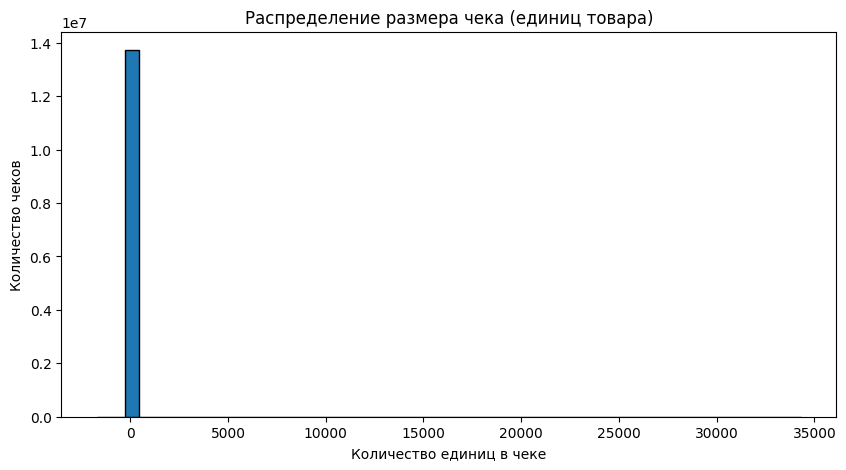

Статистики размера чека:
  Среднее: 16.42
  Медиана: 8.74
  Стандартное отклонение: 38.25
  Минимум: -1725.0
  Максимум: 34314.0
  95-й перцентиль: 58.00

Статистики по количеству уникальных подкатегорий в чеке:
  Среднее: 8.85
  Медиана: 6.00
  Стандартное отклонение: 8.94
  Минимум: 1
  Максимум: 142
  95-й перцентиль: 27.00

Топ-10 самых частых категорий (по доле чеков):
cat_name
Упаковочные и подсобные материалы                 34.76
Хлеб промышленный ржаной, ржано-пшеничный         13.85
Хлеб промышленный пшеничный                       13.85
Вода                                              13.24
Хлеб собственное производство                     12.31
Томаты                                            12.30
Молоко пастеризованное                            12.18
Йогурты и творожные десерты холодного хранения    11.83
Огурцы                                            11.62
Лимонады                                          11.29
Name: ChequeId, dtype: float64

Топ-10 категорий по об

In [ ]:

# Общее количество уникальных чеков
total_cheques = df['ChequeId'].nunique()
print(f"Общее количество чеков: {total_cheques}")

# Общее количество позиций (строк) – каждая строка = одна покупка подкатегории
total_rows = len(df)
print(f"Общее количество позиций (строк): {total_rows}")

# Если есть колонка с количеством, то общий объём продаж в штуках
if 'Штуки товаров в категории' in df.columns:
    total_units = df['Штуки товаров в категории'].sum()
    print(f"Общий объём проданных товаров (штук): {total_units}")
    
    # Среднее количество позиций на чек (в штуках)
    units_per_cheque = df.groupby('ChequeId')['Штуки товаров в категории'].sum()
    avg_units_per_cheque = units_per_cheque.mean()
    print(f"Среднее количество единиц на чек: {avg_units_per_cheque:.2f}")
else:
    print("Колонка с количеством не найдена. Метрики объёма недоступны.")

# Уникальное количество категорий и подкатегорий
if 'cat_name' in df.columns:
    unique_cats = df['cat_name'].nunique()
    print(f"Уникальных категорий: {unique_cats}")
unique_subcats = df['sub_cat_name'].nunique()
print(f"Уникальных подкатегорий: {unique_subcats}")

# Размер чека (количество единиц)

if 'Штуки товаров в категории' in df.columns:
    cheque_sizes = df.groupby('ChequeId')['Штуки товаров в категории'].sum()
    
    # Гистограмма распределения размера чека
    plt.figure(figsize=(10,5))
    plt.hist(cheque_sizes, bins=50, edgecolor='black')
    plt.title('Распределение размера чека (единиц товара)')
    plt.xlabel('Количество единиц в чеке')
    plt.ylabel('Количество чеков')
    plt.show()
    
    # Статистики
    print("Статистики размера чека:")
    print(f"  Среднее: {cheque_sizes.mean():.2f}")
    print(f"  Медиана: {cheque_sizes.median():.2f}")
    print(f"  Стандартное отклонение: {cheque_sizes.std():.2f}")
    print(f"  Минимум: {cheque_sizes.min()}")
    print(f"  Максимум: {cheque_sizes.max()}")
    print(f"  95-й перцентиль: {cheque_sizes.quantile(0.95):.2f}")
else:
    print("Нет данных о количестве – размер чека в единицах не вычислить.")

# Количество уникальных подкатегорий в чеке (SKU-богатство)
unique_subcats_per_cheque = df.groupby('ChequeId')['sub_cat_name'].nunique()
print("\nСтатистики по количеству уникальных подкатегорий в чеке:")
print(f"  Среднее: {unique_subcats_per_cheque.mean():.2f}")
print(f"  Медиана: {unique_subcats_per_cheque.median():.2f}")
print(f"  Стандартное отклонение: {unique_subcats_per_cheque.std():.2f}")
print(f"  Минимум: {unique_subcats_per_cheque.min()}")
print(f"  Максимум: {unique_subcats_per_cheque.max()}")
print(f"  95-й перцентиль: {unique_subcats_per_cheque.quantile(0.95):.2f}")

# Анализ по категориям / подкатегориям

level = 'cat_name' if 'cat_name' in df.columns else 'sub_cat_name'

# Частота встречаемости (доля чеков, содержащих данную категорию)
category_cheque_counts = df.groupby(level)['ChequeId'].nunique()
category_freq = (category_cheque_counts / total_cheques) * 100
print("\nТоп-10 самых частых категорий (по доле чеков):")
print(category_freq.sort_values(ascending=False).head(10).round(2))

# Общий объём продаж в штуках (если есть Quantity)
if 'Штуки товаров в категории' in df.columns:
    category_units = df.groupby(level)['Штуки товаров в категории'].sum().sort_values(ascending=False)
    print("\nТоп-10 категорий по объёму продаж (штуки):")
    print(category_units.head(10))
    
    # Среднее количество в чеке для каждой категории
    category_avg_per_cheque = (category_units / category_cheque_counts).sort_values(ascending=False)
    print("\nТоп-10 категорий по среднему количеству на чек (штук):")
    print(category_avg_per_cheque.head(10).round(2))
    


# Сеть связей + кластеризация Leiden

In [ ]:
df = df[[
    "ChequeId",
    "sub_cat_name"
]].copy()

df = df.dropna(subset=["sub_cat_name"])

In [ ]:
df["ChequeId"] = df["ChequeId"].astype("int64")
df["sub_cat_name"] = df["sub_cat_name"].astype("category")

In [ ]:
pair_counter = Counter()

grouped = df.groupby("ChequeId")["sub_cat_name"]

for _, basket in grouped:
    items = basket.values
    
    if len(items) > 1:
        pair_counter.update(
            combinations(sorted(items), 2)
        )

# Освобождаем память
del df
gc.collect()

print("Всего пар:", len(pair_counter))

Всего пар: 1719523


In [ ]:
MIN_SUPPORT = 500

filtered_pairs = {
    pair: weight
    for pair, weight in pair_counter.items()
    if weight >= MIN_SUPPORT
}

del pair_counter
gc.collect()

print("После фильтра:", len(filtered_pairs))

После фильтра: 258032


In [ ]:
# узлы
nodes = set()
for a, b in filtered_pairs.keys():
    nodes.add(a)
    nodes.add(b)

nodes = list(nodes)
node_index = {node: idx for idx, node in enumerate(nodes)}

edges = []
weights = []

for (a, b), w in filtered_pairs.items():
    edges.append((node_index[a], node_index[b]))
    weights.append(w)

g = ig.Graph()
g.add_vertices(len(nodes))
g.add_edges(edges)
g.es["weight"] = weights

print(g.summary())

IGRAPH U-W- 1704 258032 -- 
+ attr: weight (e)


In [ ]:
partition = leidenalg.find_partition(
    g,
    leidenalg.RBConfigurationVertexPartition,
    weights="weight",
    resolution_parameter=1.0
)

clusters = partition.membership

In [ ]:
results = pd.DataFrame({
    "sub_cat_name": nodes,
    "cluster": clusters
})

print(results["cluster"].value_counts())

results.to_csv("/Users/veronikakozlova/Documents/ВКР HSE /leiden_clusters.csv", index=False)

cluster
0    738
1    376
2    225
3    200
4    152
5     13
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

num_clusters = len(set(clusters))

cmap = plt.cm.tab20
color_array = cmap(np.linspace(0, 1, num_clusters))

# переводим RGBA → HEX
hex_colors = [mcolors.to_hex(c) for c in color_array]

cluster_color_map = {
    cluster: hex_colors[i]
    for i, cluster in enumerate(sorted(set(clusters)))
}

vertex_colors = [
    cluster_color_map[c]
    for c in clusters
]

In [ ]:
edge_weights = g.es["weight"]
max_weight = max(edge_weights)

edge_widths = [1 + 4*(w/max_weight) for w in edge_weights]

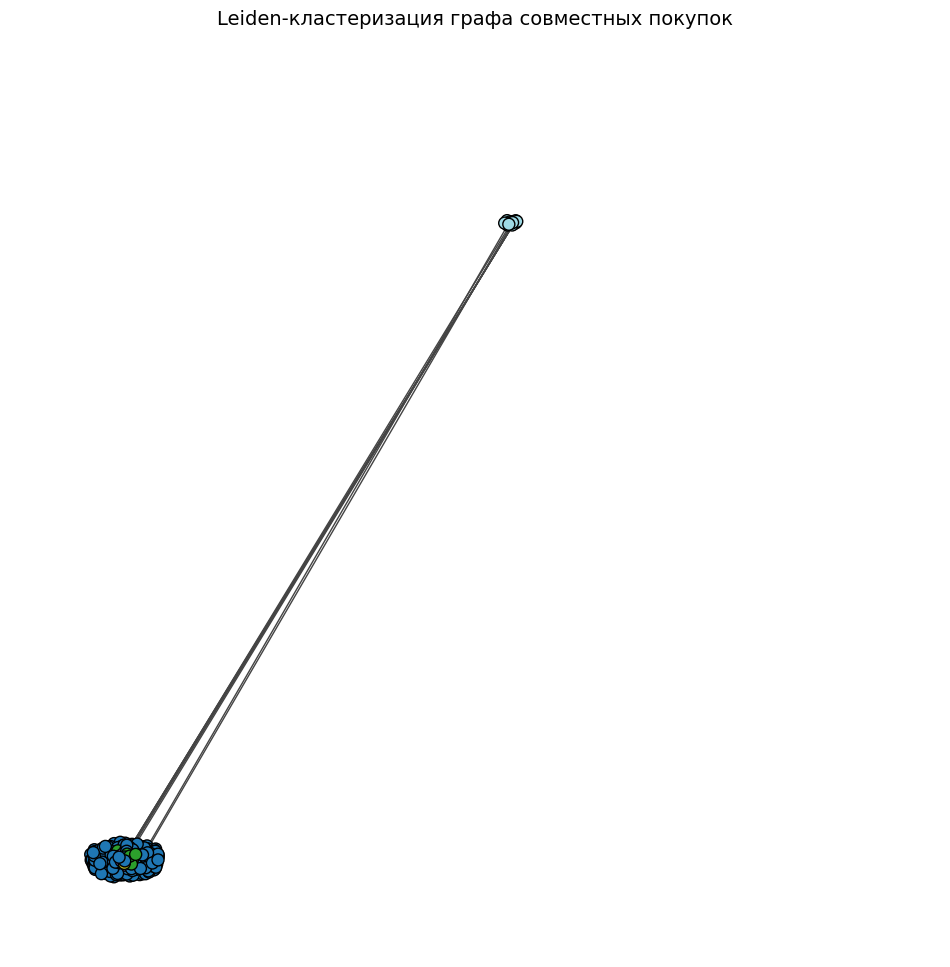

In [ ]:
layout = g.layout("drl")
fig, ax = plt.subplots(figsize=(12, 12))

ig.plot(
    g,
    target=ax,
    layout=layout,
    vertex_size=12,
    vertex_color=vertex_colors,
    vertex_label=None,
    edge_width=edge_widths
)

plt.title("Leiden-кластеризация графа совместных покупок", fontsize=14)
plt.show()